## Bernardo Frederick Kowe - 0706022310049

## Loading Library

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)


!pip install mlxtend==0.23.1

# **A Day in the Life of a Data Analyst: Unraveling Insights from The Bread Basket Dataset**

---

**Thursday, December 5** <br>
As the sun rises on another busy Thursday, I settle into my workspace, ready to dive into The Bread Basket dataset. This dataset is a treasure trove of information, capturing the essence of customer transactions at a local bakery. My goal today is to uncover insights that can help the bakery optimize its offerings and enhance customer satisfaction.


## **Loading Dataset**
I start my day by loading the dataset into my Python environment. Yesterday, I got the dataset from my [Client](https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/bread%20basket%20(1).csv). Using Pandas, I import the data and take a moment to familiarize myself with its structure.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
#1
df = pd.read_csv("/content/drive/MyDrive/Data Mining/W13/bread basket.csv")
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


As I glance through the initial rows, I see the columns: Transaction, Item, date_time, period_day, and weekday_weekend. Each transaction is unique, and I can already sense the potential insights hidden within.

## **Exploratory Data Analysis (EDA)**
With the dataset loaded, I transition into Exploratory Data Analysis (EDA). This phase is crucial for understanding the data better and identifying patterns.
### **Data Overview**
I begin by checking for missing values and summarizing the basic statistics of the dataset.

In [15]:
#2 info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [18]:
#3 check missing values
df.isnull().sum()

,0
Transaction,0
Item,0
date_time,0
period_day,0
weekday_weekend,0


4. The overview reveals a _________________________. (fill that blank on the section below)

The overview reveals a need to convert the 'date_time' column to a datetime type (or clean dataset with no missing values).

### **Transaction Trends**
Next, I analyze transaction trends over time. I extract the date and hour from the date_time column to see how customer purchases vary throughout the day and week. Then, I visualize the daily transaction trends to identify peak days and times for customer activity.

In [23]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['Date'] = df['date_time'].dt.date
df['Hour'] = df['date_time'].dt.hour
daily_transactions = df.groupby('Date')['Transaction'].count()

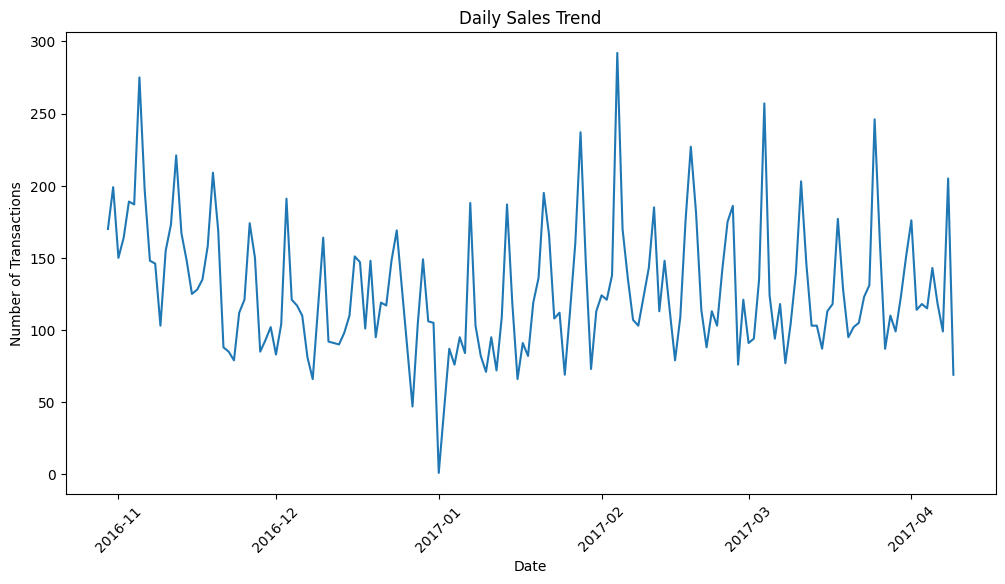

In [24]:
# 5
plt.figure(figsize=(12, 6))
daily_transactions.plot(kind='line')
plt.xticks(rotation=45)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(False)
plt.show()



Oh my God, it's so difficult to get insights from this visualization, but it seems like there might be a trend to uncover. Let me try separating it by the perspective of hour, time, day, day_name, month, and year by adding each of those variabels into the dataframe.

In [29]:
# 6
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['time'] = df['date_time'].dt.time
df['hour'] = df['date_time'].dt.hour
df['day_name'] = df['date_time'].dt.day_name()

df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,day,month,year,time,hour,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,10,2016,09:58:00,9,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10,2016,10:05:00,10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10,2016,10:05:00,10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10,2016,10:07:00,10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10,2016,10:07:00,10,Sunday



Alright, now I can easily create a visualization of monthly sales.

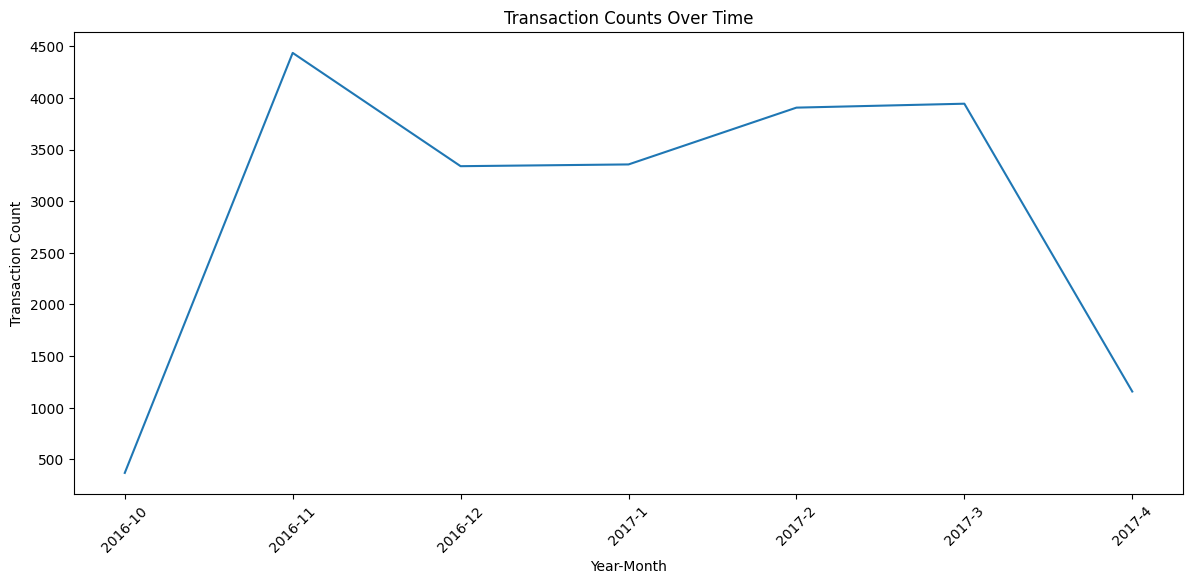

In [38]:
# 7
df['Year-Month'] = df['year'].astype(str) + '-' + df['month'].astype(str)
monthly_transactions = df.groupby('Year-Month')['Transaction'].count()

plt.figure(figsize=(14.3, 6))
monthly_transactions.plot(kind='line')

plt.title('Transaction Counts Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.grid(False)
plt.show()


8. Now, the visualization above provides better insights: _________________________. (fill that blank on the section below)

Now, the visualization above provides better insights: The peak transaction count occurred in November 2016, followed by a noticeable dip in December 2016, and then stabilized at a high level between February and March 2017.

Next, I want to see if there's a trend for each day of the week in each month.
Oh, the dataframe has a column called weekday_weekend. What days include weekends and weekdays??

In [40]:
#9
unique_weekday_names = df[df['weekday_weekend'] == 'weekday']['day_name'].unique()

unique_weekend_names = df[df['weekday_weekend'] == 'weekend']['day_name'].unique()

print(f"Unique weekday names: {unique_weekday_names}")
print(f"Unique weekend names: {unique_weekend_names}")

Unique weekday names: ['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday']
Unique weekend names: ['Sunday' 'Saturday']



Oh, okay, now I know that "weekend" refers to Sunday and Saturday. Alright, moving on, before creating the visualization, it seems necessary to create an aggregation with the columns for the month and day name, where the values represent the total transactions that occurred.

In [43]:
#10
sales_by_month_day = df.groupby(['month', 'day_name'])['Transaction'].count().reset_index()
sales_pivot = sales_by_month_day.pivot(index='month', columns='day_name', values='Transaction').fillna(0)
sales_pivot = sales_pivot.astype(int)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_pivot = sales_pivot[day_order]

sales_pivot


day_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
month,,,,,,,
1,329,474,322,399,489,807,536
2,474,429,419,456,599,879,650
3,379,433,459,557,674,883,559
4,118,115,143,118,99,381,183
10,199,0,0,0,0,0,170
11,469,599,576,591,639,879,683
12,356,342,402,525,624,776,314


11. Wow, it turns out the insight that can be gained from the table above is _____

Wow, it turns out the insight that can be gained from the table above is Transaction counts are consistently highest on the weekend, specifically Saturday and Sunday, across almost all months, with Saturday being the busiest day.


It seems ready to create the visualization now. Okay, I will create a comparison visualization of total sales per day for each month.

In [46]:
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,day,month,year,time,hour,day_name,Year-Month
0,1,Bread,2016-10-30 09:58:00,morning,weekend,30,10,2016,09:58:00,9,Sunday,2016-10
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10,2016,10:05:00,10,Sunday,2016-10
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,30,10,2016,10:05:00,10,Sunday,2016-10
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,30,10,2016,10:07:00,10,Sunday,2016-10
4,3,Jam,2016-10-30 10:07:00,morning,weekend,30,10,2016,10:07:00,10,Sunday,2016-10


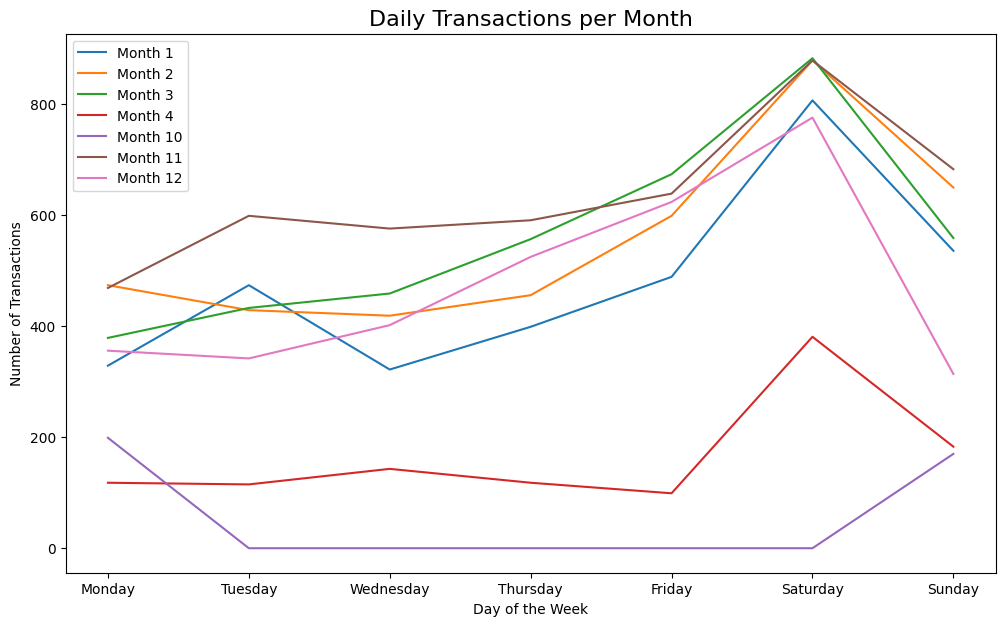

In [52]:
# 12
import seaborn as sns

sales_long = sales_pivot.stack().reset_index(name='Number of Transactions')

sales_long = sales_long.rename(columns={'day_name': 'Day of the Week'})

relevant_months = [1, 2, 3, 4, 10, 11, 12]
sales_long_filtered = sales_long[sales_long['month'].isin(relevant_months)]

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=sales_long_filtered,
    x='Day of the Week',
    y='Number of Transactions',
    hue='month',
    palette=sns.color_palette("tab10", n_colors=7),
    errorbar=None,
)

plt.title('Daily Transactions per Month', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')

legend_order = [1, 2, 3, 4, 10, 11, 12]
handles, labels = plt.gca().get_legend_handles_labels()
int_labels = [int(label) for label in labels]
order = [int_labels.index(m) for m in legend_order if m in int_labels]

handles = [handles[i] for i in order]
labels = [f"Month {legend_order[i]}" for i in range(len(legend_order))]

plt.legend(handles, labels, title=None, loc='upper left')

plt.xticks(ticks=range(len(day_order)), labels=day_order)
plt.grid(False)
plt.show()

13. Wow, after visualizing it like this, I can gain insights into the sales trends that ____.

Wow, after visualizing it like this, I can gain insights into the sales trends that show a highly consistent daily pattern across all months, where transactions significantly peak on Saturdays and drop to the lowest levels during the mid-week.

Oh, it turns out there's also a "period_day" column in the dataframe, but at the beginning, I only noticed "morning." Hmm, I'm curious, what other unique values could there be?

In [54]:
# 14
df['period_day'].unique()

array(['morning', 'afternoon', 'evening', 'night'], dtype=object)

Oh, okay, there are "morning," "afternoon," "evening," and "night."
But, but, but, what are the time ranges for morning, afternoon, evening, and night? Let me try to find out.

In [56]:
# 15
unique_morning_hour = df[df['period_day'] == 'morning']['hour'].unique()
unique_afternoon_hour = df[df['period_day'] == 'afternoon']['hour'].unique()
unique_evening_hour = df[df['period_day'] == 'evening']['hour'].unique()
unique_night_hour = df[df['period_day'] == 'night']['hour'].unique()

print(f"Unique morning_hour: {unique_morning_hour}")
print(f"Unique afternoon_hour: {unique_afternoon_hour}")
print(f"Unique evening_hour: {unique_evening_hour}")
print(f"Unique night_hour: {unique_night_hour}")

Unique morning_hour: [ 9 10 11  8  7  1]
Unique afternoon_hour: [12 13 14 15 16]
Unique evening_hour: [17 18 19 20]
Unique night_hour: [21 23 22]


16. Hah, I found something odd in the results above. Did you notice it too? What do you think is odd about it and why?

The odd part is that hour 1 (1 AM) is included in the 'morning' period rather than 'night' or being absent entirely. This is strange because 'morning' typically starts much later (e.g., 6 AM or 7 AM). It suggests that the data categorization for 'period_day' is not strictly based on a standard 24-hour clock definition, or perhaps there was a rare transaction at 1 AM that was incorrectly tagged as 'morning' in the original dataset creation process.


But that's okay, I'll just continue exploring the insights. It seems like I can create a sales analysis based on the hours of each day here.

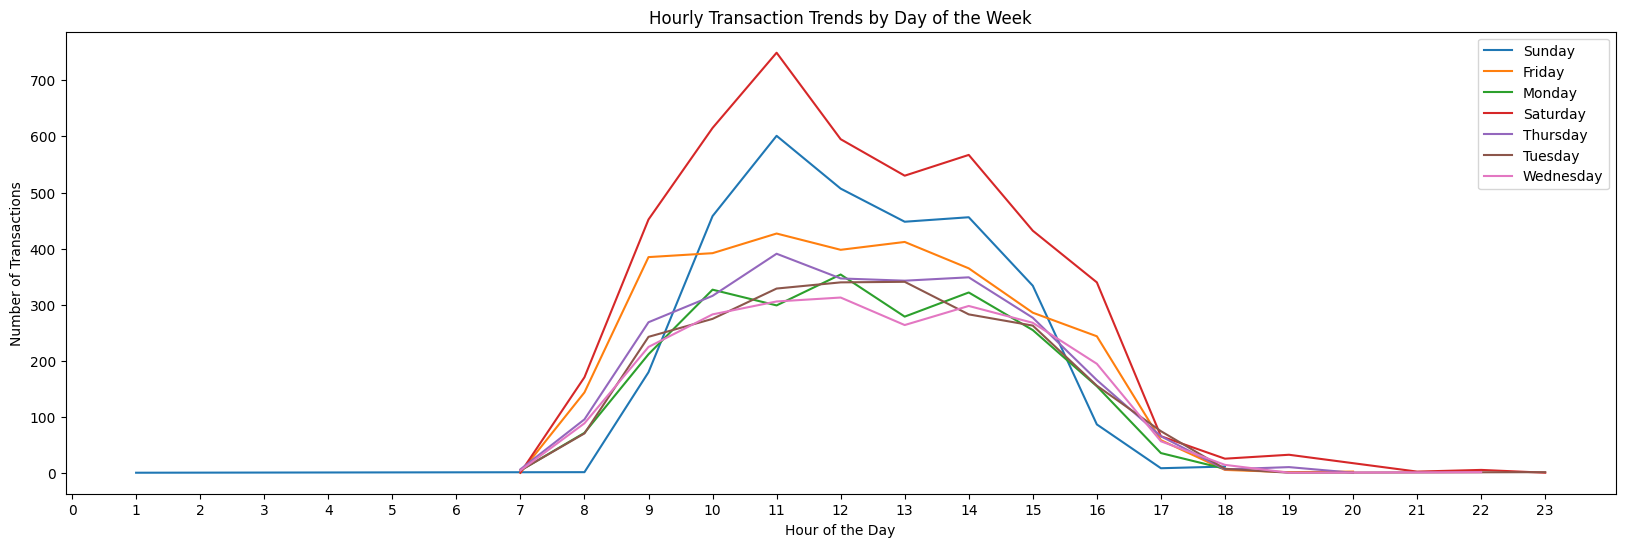

In [62]:
# 17
import seaborn as sns

hourly_sales_by_day = df.groupby(['hour', 'day_name'])['Transaction'].count().reset_index(name='Number of Transactions')

day_order = ['Sunday', 'Friday', 'Monday', 'Saturday', 'Thursday', 'Tuesday', 'Wednesday']

plt.figure(figsize=(20, 6))
sns.lineplot(
    data=hourly_sales_by_day,
    x='hour',
    y='Number of Transactions',
    hue='day_name',
    hue_order=day_order,
    errorbar=None
)

plt.title('Hourly Transaction Trends by Day of the Week')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')

plt.xticks(range(0, 24, 1))
plt.legend(title=None, loc='upper right')

plt.grid(False)
plt.show()


18. The daily sales trend plot reveals that ___________

The daily sales trend plot reveals that Saturday and Sunday exhibit significantly higher transaction peaks than weekdays, with the overall peak activity occurring consistently between 11 AM and 1 PM for all days.

### **Item Popularity**
Curious about which items are most popular, I analyze the frequency of orders for each item.

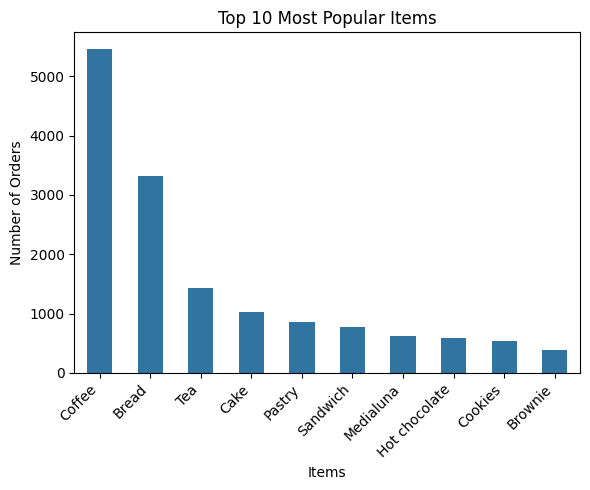

In [74]:
# 19
import seaborn as sns

item_counts = df['Item'].value_counts()
top_10_items = item_counts.head(10)

plt.figure(figsize=(6, 5))
sns.barplot(
    x=top_10_items.index,
    y=top_10_items.values,
    color='tab:blue',
    width=0.5
)

plt.title('Top 10 Most Popular Items')
plt.xlabel('Items')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Hmm, but this is overall data. I want to create a visualization by period instead, maybe the highest sales vary by period.

/tmp/ipython-input-3861822147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


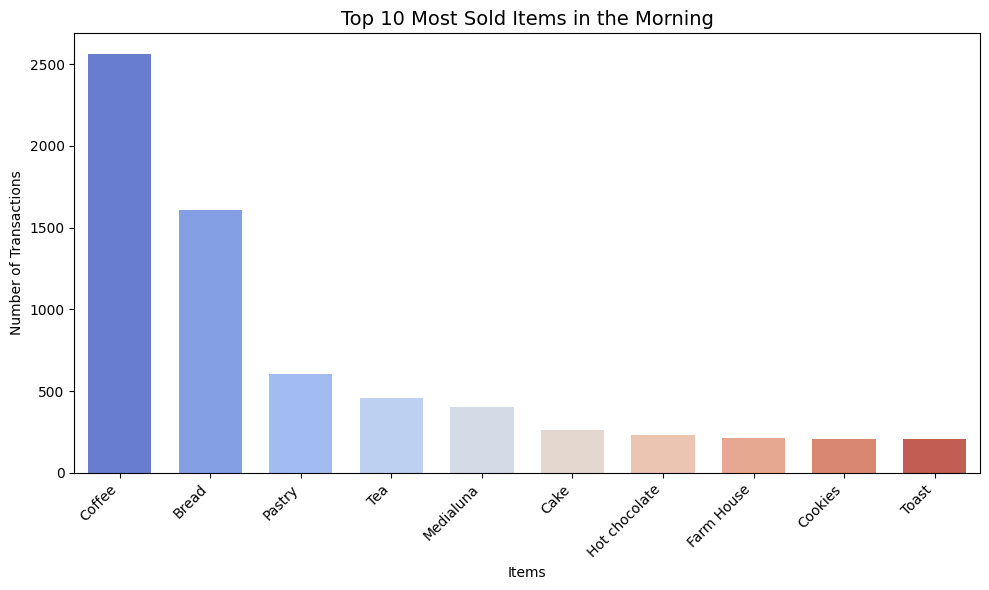

/tmp/ipython-input-3861822147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


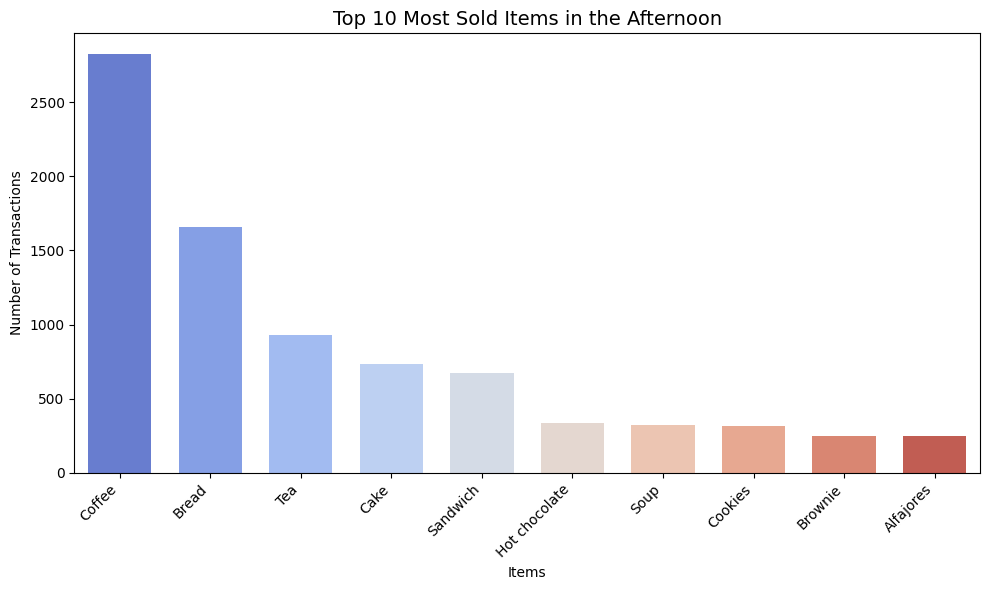

/tmp/ipython-input-3861822147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


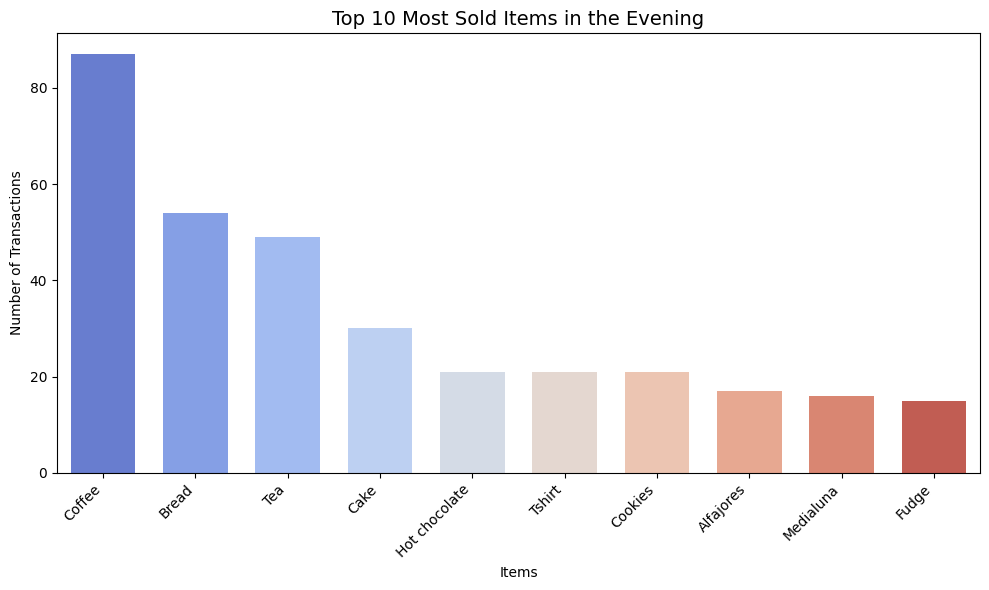

/tmp/ipython-input-3861822147.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


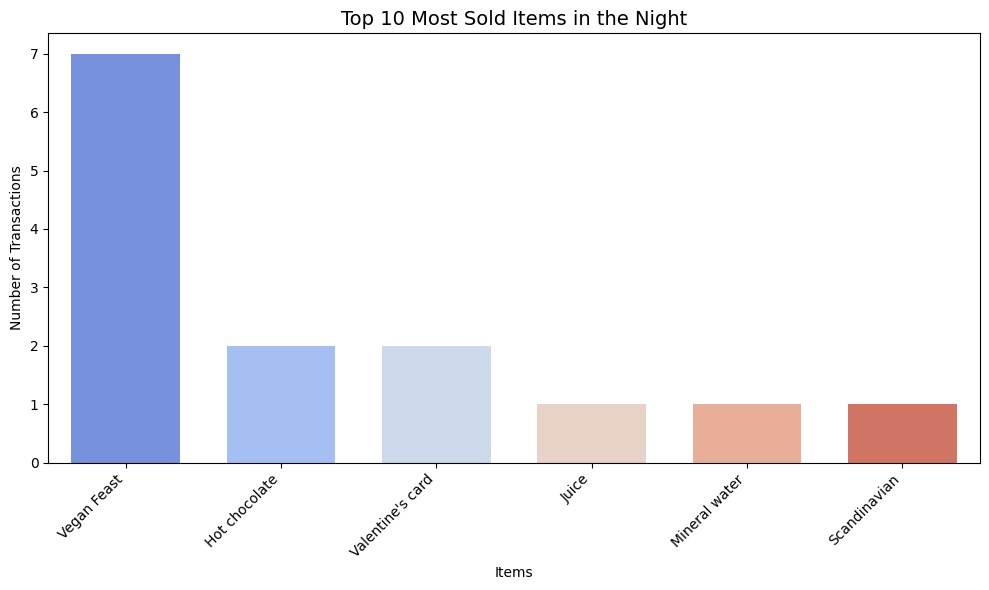

In [76]:
# 20
import seaborn as sns

period_list = ['morning', 'afternoon', 'evening', 'night']

for period in period_list:
    df_period = df[df['period_day'] == period]

    item_counts = df_period[df_period['Item'] != 'NONE']['Item'].value_counts()
    top_10_items = item_counts.head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=top_10_items.index,
        y=top_10_items.values,
        palette='coolwarm',
        width=0.7
    )

    plt.title(f'Top 10 Most Sold Items in the {period.capitalize()}', fontsize=14)
    plt.xlabel('Items')
    plt.ylabel('Number of Transactions')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


21. It turns out that there is something different in the plot above, the insight is ____


It turns out that there is something different in the plot above, the insight is the best-selling items drastically change during the 'Night' period; 'Coffee' and 'Bread' are no longer the top sellers, being replaced by 'Vegan Feast' and 'Hot chocolate', indicating a shift from general bakery sales to specific late-night/specialty items

I found a valentine card, I was curious about when people bought it so I made a visualization of it

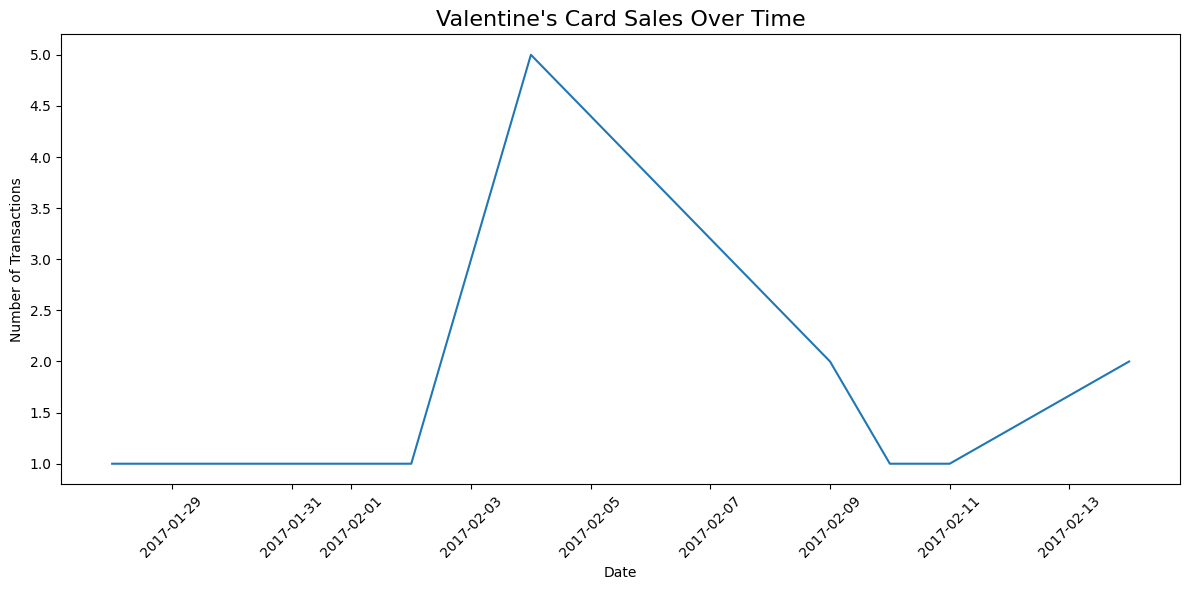

In [84]:
#22
df_valentine = df[df['Item'] == "Valentine's card"].copy()
df_valentine['Date'] = df_valentine['date_time'].dt.date

valentine_sales = df_valentine.groupby('Date')['Transaction'].count().reset_index(name='Number of Transactions')

plt.figure(figsize=(12, 6))
plt.plot(valentine_sales['Date'], valentine_sales['Number of Transactions'])
plt.title("Valentine's Card Sales Over Time", fontsize=16)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()


23. I found the insight from the sale of the Valentine's cards above is ____


I found the insight from the sale of the Valentine's cards above is the sales peaked significantly on February 4th, 2017 (reaching 5 transactions), which indicates that customers purchased the card approximately 10 days before Valentine's Day (February 14th).

## **Applying the Apriori Algorithm**
With a solid understanding of the data, I shift my focus to identifying associations between items using the Apriori algorithm.

### **Data Preparation for Apriori**
I need to transform the dataset into a format suitable for the Apriori algorithm, where each transaction is represented as a row and each item as a column.

In [86]:
# 24
df_filtered = df[df['Item'] != 'NONE']
df_filtered['Presence'] = 1

basket_encoded = df_filtered.groupby(['Transaction', 'Item'])['Presence'].sum().unstack().fillna(0)
basket_encoded.head()


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [87]:
#25
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_final = basket_encoded.applymap(encode_units)
basket_final.head()


/tmp/ipython-input-1886448955.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_final = basket_encoded.applymap(encode_units)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Finding Frequent Itemsets**
Now, I apply the Apriori algorithm to find frequent itemsets with a minimum support threshold. This will help identify combinations of items that are frequently purchased together. Apriori: (min_support=0.02), Association Rules: (metric="lift", min_threshold=1)

In [93]:
# 26
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(basket_final, min_support=0.02, use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: list(x))
frequent_itemsets.head(35)


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
4,0.478394,[Coffee]
1,0.327205,[Bread]
16,0.142631,[Tea]
3,0.103856,[Cake]
20,0.090016,"[Coffee, Bread]"
11,0.086107,[Pastry]
12,0.071844,[Sandwich]
9,0.061807,[Medialuna]
7,0.058320,[Hot chocolate]
23,0.054728,"[Coffee, Cake]"


In [100]:
# 27
rules['jaccard'] = rules['support'] / (rules['antecedent support'] + rules['consequent support'] - rules['support'])
confidence_b_to_a = rules['support'] / rules['consequent support']
rules['kulczynski'] = 0.5 * (rules['confidence'] + confidence_b_to_a)
rules['representativity'] = 1.0
rules['certainty'] = rules['confidence']
rules['zhangs_metric'] = (rules['lift'] - 1) / (np.maximum(rules['consequent support'] / rules['antecedent support'], rules['antecedent support'] / rules['consequent support']) - 1) # Ini adalah proxy rumus korelasi
rules_sorted = rules.sort_values(by="lift", ascending=False)

rules_sorted = rules_sorted.reset_index(drop=True)

rules_sorted['antecedents'] = rules_sorted['antecedents'].apply(lambda x: list(x))
rules_sorted['consequents'] = rules_sorted['consequents'].apply(lambda x: list(x))

rules_sorted[[
    'antecedents', 'consequents', 'antecedent support', 'consequent support',
    'support', 'confidence', 'lift',
    'representativity', 'leverage', 'conviction',
    'zhangs_metric', 'jaccard', 'certainty', 'kulczynski'
]].head(20)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,[Tea],[Cake],0.142631,0.103856,0.023772,0.166667,1.604781,1.0,0.008959,1.075372,1.619891,0.106736,0.166667,0.197779
1,[Cake],[Tea],0.103856,0.142631,0.023772,0.228891,1.604781,1.0,0.008959,1.111865,1.619891,0.106736,0.228891,0.197779
2,[Toast],[Coffee],0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.035685,0.048464,0.704403,0.376936
3,[Coffee],[Toast],0.478394,0.033597,0.023666,0.049470,1.472431,1.0,0.007593,1.016699,0.035685,0.048464,0.049470,0.376936
4,[Medialuna],[Coffee],0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.028171,0.069665,0.569231,0.321387
5,[Coffee],[Medialuna],0.478394,0.061807,0.035182,0.073542,1.189878,1.0,0.005614,1.012667,0.028171,0.069665,0.073542,0.321387
6,[Coffee],[Pastry],0.478394,0.086107,0.047544,0.099382,1.154168,1.0,0.006351,1.014740,0.033840,0.091968,0.099382,0.325764
7,[Pastry],[Coffee],0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.033840,0.091968,0.552147,0.325764
8,[Juice],[Coffee],0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.010236,0.041507,0.534247,0.288656
9,[Coffee],[Juice],0.478394,0.038563,0.020602,0.043065,1.116750,1.0,0.002154,1.004705,0.010236,0.041507,0.043065,0.288656


## Conclusion: The Impact of Data Analysis
28. As my day of analysis comes to a close, I compile my findings into a comprehensive report that highlights several key insights derived from The Bread Basket dataset:



As my day of analysis comes to a close, I compile my findings into a comprehensive report that highlights several key insights derived from The Bread Basket dataset:

1. Seasonal/Daily Peaks: Transaction volumes peak significantly on Saturdays and Sundays and are consistently highest between 11 AM and 1 PM daily. Peak monthly sales occurred in November 2016.
2. Core Products: Coffee and Bread remain the staple products, dominating morning and afternoon sales.
3. Time-Specific Offering: Product popularity shifts dramatically at night, indicating a need for targeted late-hour promotion of items like Vegan Feast and Hot chocolate.
4. Key Associations: The analysis confirmed the strong association between staple items, with the highest frequency itemset being {Coffee, Bread}. This informs bundling and strategic placement of these paired items.